In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

import matplotlib.pyplot as plt

In [2]:
reviews = pd.read_csv("../data/raw/reviews.csv")

print("Raw dataset shape:", reviews.shape)
display(reviews.head())

Raw dataset shape: (12495, 12)


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,gp:AOqpTOEhZuqSqqWnaKRgv-9ABYdajFUB0WugPGh-SG-...,Eric Tie,https://play-lh.googleusercontent.com/a-/AOh14...,I cannot open the app anymore,1,0,5.4.0.6,2020-10-27 21:24:41,NaN,NaN,newest,com.anydo
1,gp:AOqpTOH0WP4IQKBZ2LrdNmFy_YmpPCVrV3diEU9KGm3...,john alpha,https://play-lh.googleusercontent.com/a-/AOh14...,I have been begging for a refund from this app...,1,0,NaN,2020-10-27 14:03:28,"Please note that from checking our records, yo...",2020-10-27 15:05:52,newest,com.anydo
2,gp:AOqpTOEMCkJB8Iq1p-r9dPwnSYadA5BkPWTf32Z1azu...,Sudhakar .S,https://play-lh.googleusercontent.com/a-/AOh14...,Very costly for the premium version (approx In...,1,0,NaN,2020-10-27 08:18:40,NaN,NaN,newest,com.anydo
3,gp:AOqpTOGFrUWuKGycpje8kszj3uwHN6tU_fd4gLVFy9z...,SKGflorida@bellsouth.net DAVID S,https://play-lh.googleusercontent.com/-75aK0WF...,"Used to keep me organized, but all the 2020 UP...",1,0,NaN,2020-10-26 13:28:07,What do you find troublesome about the update?...,2020-10-26 14:58:29,newest,com.anydo
4,gp:AOqpTOHls7DW8wmDFzTkHwxuqFkdNQtKHmO6Pt9jhZE...,Louann Stoker,https://play-lh.googleusercontent.com/-pBcY_Z-...,Dan Birthday Oct 28,1,0,5.6.0.7,2020-10-26 06:10:50,NaN,NaN,newest,com.anydo


In [3]:
required_columns = {"content", "score"}

missing_columns = required_columns - set(reviews.columns)

assert not missing_columns, (
    f"Required columns are missing: {missing_columns}"
)

print("Required columns are present.")

Required columns are present.


In [4]:
reviews_clean = reviews.dropna(
    subset=["content", "score"]
).copy()

reviews_clean = reviews_clean[
    reviews_clean["content"].astype(str).str.strip().ne("")
].copy()

print("Rows before invalid-row removal:", len(reviews))
print("Rows after invalid-row removal:", len(reviews_clean))
print("Rows removed:", len(reviews) - len(reviews_clean))

Rows before invalid-row removal: 12495
Rows after invalid-row removal: 12495
Rows removed: 0


In [5]:
print("Unique scores:")
print(sorted(reviews_clean["score"].unique()))

assert set(reviews_clean["score"].unique()).issubset(
    {1, 2, 3, 4, 5}
)

print("Score validation passed.")

Unique scores:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Score validation passed.


In [6]:
def score_to_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"


reviews_clean["sentiment"] = reviews_clean["score"].apply(
    score_to_sentiment
)

print(reviews_clean["sentiment"].value_counts())

sentiment
positive    5654
negative    4850
neutral     1991
Name: count, dtype: int64


In [7]:
reviews_clean["normalised"] = (
    reviews_clean["content"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

In [8]:
label_counts_per_text = (
    reviews_clean
    .groupby("normalised")["sentiment"]
    .nunique()
)

conflicting_texts = label_counts_per_text[
    label_counts_per_text > 1
].index

model_reviews = reviews_clean[
    ~reviews_clean["normalised"].isin(conflicting_texts)
].copy()

In [9]:
model_reviews = model_reviews.drop_duplicates(
    subset=["normalised", "sentiment"]
).copy()

print("Rows after cleaning:", len(model_reviews))

print("\nRemaining conflicting text groups:")
print(
    model_reviews.groupby("normalised")["sentiment"]
    .nunique()
    .gt(1)
    .sum()
)

print("\nRemaining duplicate text-label pairs:")
print(
    model_reviews.duplicated(
        subset=["normalised", "sentiment"]
    ).sum()
)

print("\nClass distribution:")
print(model_reviews["sentiment"].value_counts())

Rows after cleaning: 11684

Remaining conflicting text groups:
0

Remaining duplicate text-label pairs:
0

Class distribution:
sentiment
positive    5064
negative    4734
neutral     1886
Name: count, dtype: int64


In [10]:
x = model_reviews["normalised"]
y = model_reviews["sentiment"]

print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (11684,)
y shape: (11684,)


In [11]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (9347,)
x_test: (2337,)
y_train: (9347,)
y_test: (2337,)


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

print("Training TF-IDF shape:", x_train_tfidf.shape)
print("Testing TF-IDF shape:", x_test_tfidf.shape)

Training TF-IDF shape: (9347, 10919)
Testing TF-IDF shape: (2337, 10919)


In [13]:
assert len(x_train) == len(y_train)
assert len(x_test) == len(y_test)
assert x_train_tfidf.shape[1] == x_test_tfidf.shape[1]
assert set(y.unique()) == {"negative", "neutral", "positive"}
assert model_reviews["normalised"].isna().sum() == 0

print("All pipeline checks passed.")

All pipeline checks passed.


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)


LABELS = ["negative", "neutral", "positive"]


def evaluate_model(y_true, predictions):
   
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        predictions,
        labels=LABELS,
        zero_division=0
    )

   
    macro_f1 = precision_recall_fscore_support(
        y_true,
        predictions,
        average="macro",
        zero_division=0
    )[2]

   
    weighted_f1 = precision_recall_fscore_support(
        y_true,
        predictions,
        average="weighted",
        zero_division=0
    )[2]

    return {
        "accuracy": float(accuracy_score(y_true, predictions)),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "negative_f1": float(f1[0]),
        "neutral_f1": float(f1[1]),
        "positive_f1": float(f1[2])
    }

In [15]:
from sklearn.linear_model import LogisticRegression


unweighted_logreg_model = LogisticRegression(
    max_iter=1000,
    class_weight=None,
    random_state=42
)

unweighted_logreg_model.fit(
    x_train_tfidf,
    y_train
)

unweighted_logreg_predictions = unweighted_logreg_model.predict(
    x_test_tfidf
)

unweighted_logreg_metrics = evaluate_model(
    y_test,
    unweighted_logreg_predictions
)

print("Unweighted Logistic Regression:")
print(unweighted_logreg_metrics)

Unweighted Logistic Regression:
{'accuracy': 0.7355584082156611, 'macro_f1': 0.5913108356290174, 'weighted_f1': 0.6994494925919246, 'negative_f1': 0.7878787878787878, 'neutral_f1': 0.17355371900826447, 'positive_f1': 0.8125}


In [16]:
balanced_logreg_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

balanced_logreg_model.fit(
    x_train_tfidf,
    y_train
)

balanced_logreg_predictions = balanced_logreg_model.predict(
    x_test_tfidf
)

balanced_logreg_metrics = evaluate_model(
    y_test,
    balanced_logreg_predictions
)

print("Balanced Logistic Regression:")
print(balanced_logreg_metrics)

Balanced Logistic Regression:
{'accuracy': 0.686777920410783, 'macro_f1': 0.6275955279143733, 'weighted_f1': 0.7007243655691404, 'negative_f1': 0.735973597359736, 'neutral_f1': 0.34763476347634764, 'positive_f1': 0.7991782229070364}


In [17]:
from sklearn.svm import LinearSVC


balanced_svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

balanced_svm_model.fit(
    x_train_tfidf,
    y_train
)

balanced_svm_predictions = balanced_svm_model.predict(
    x_test_tfidf
)

balanced_svm_metrics = evaluate_model(
    y_test,
    balanced_svm_predictions
)

print("Balanced Linear SVM:")
print(balanced_svm_metrics)

Balanced Linear SVM:
{'accuracy': 0.6953359007274283, 'macro_f1': 0.6043957916924086, 'weighted_f1': 0.6902751680729748, 'negative_f1': 0.743455497382199, 'neutral_f1': 0.2743988684582744, 'positive_f1': 0.7953330092367525}


In [18]:
assert len(unweighted_logreg_predictions) == len(y_test)
assert len(balanced_logreg_predictions) == len(y_test)
assert len(balanced_svm_predictions) == len(y_test)

assert set(unweighted_logreg_predictions).issubset(set(LABELS))
assert set(balanced_logreg_predictions).issubset(set(LABELS))
assert set(balanced_svm_predictions).issubset(set(LABELS))

print("All model prediction checks passed.")

All model prediction checks passed.


In [19]:
model_results = pd.DataFrame([
    {
        "model": "Logistic Regression — Unweighted",
        **unweighted_logreg_metrics
    },
    {
        "model": "Logistic Regression — Balanced",
        **balanced_logreg_metrics
    },
    {
        "model": "Linear SVM — Balanced",
        **balanced_svm_metrics
    }
])

model_results = model_results.round(4)

display(
    model_results.sort_values(
        by="macro_f1",
        ascending=False
    )
)

,model,accuracy,macro_f1,weighted_f1,negative_f1,neutral_f1,positive_f1
1,Logistic Regression — Balanced,0.6868,0.6276,0.7007,0.7360,0.3476,0.7992
2,Linear SVM — Balanced,0.6953,0.6044,0.6903,0.7435,0.2744,0.7953
0,Logistic Regression — Unweighted,0.7356,0.5913,0.6994,0.7879,0.1736,0.8125


In [20]:
tfidf_unigram_bigram = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

x_train_tfidf_bigram = tfidf_unigram_bigram.fit_transform(
    x_train
)

x_test_tfidf_bigram = tfidf_unigram_bigram.transform(
    x_test
)

assert (
    x_train_tfidf_bigram.shape[1]
    == x_test_tfidf_bigram.shape[1]
)

print("Unigram features:", x_train_tfidf.shape[1])
print(
    "Unigram + bigram features:",
    x_train_tfidf_bigram.shape[1]
)

print("Bigram training shape:", x_train_tfidf_bigram.shape)
print("Bigram testing shape:", x_test_tfidf_bigram.shape)
print("Bigram TF-IDF checks passed.")

Unigram features: 10919
Unigram + bigram features: 29501
Bigram training shape: (9347, 29501)
Bigram testing shape: (2337, 29501)
Bigram TF-IDF checks passed.


In [21]:
balanced_logreg_bigram_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

balanced_logreg_bigram_model.fit(
    x_train_tfidf_bigram,
    y_train
)

balanced_logreg_bigram_predictions = (
    balanced_logreg_bigram_model.predict(
        x_test_tfidf_bigram
    )
)

assert len(balanced_logreg_bigram_predictions) == len(y_test)

balanced_logreg_bigram_metrics = evaluate_model(
    y_test,
    balanced_logreg_bigram_predictions
)

print("Balanced Logistic Regression — Unigrams + Bigrams:")
print(balanced_logreg_bigram_metrics)

Balanced Logistic Regression — Unigrams + Bigrams:
{'accuracy': 0.7051775780915703, 'macro_f1': 0.6368017294713241, 'weighted_f1': 0.7130135351090929, 'negative_f1': 0.7549597855227882, 'neutral_f1': 0.3444976076555024, 'positive_f1': 0.8109477952356817}


In [23]:
bigram_result = pd.DataFrame([
    {
        "model": "Logistic Regression — Balanced — Unigrams + Bigrams",
        **balanced_logreg_bigram_metrics
    }
])

model_results = pd.concat(
    [model_results, bigram_result],
    ignore_index=True
)

model_results = (
    model_results
    .drop_duplicates(
        subset=["model"],
        keep="last"
    )
    .round(4)
)

display(
    model_results.sort_values(
        by="macro_f1",
        ascending=False
    )
)

,model,accuracy,macro_f1,weighted_f1,negative_f1,neutral_f1,positive_f1
4,Logistic Regression — Balanced — Unigrams + Bi...,0.7052,0.6368,0.7130,0.7550,0.3445,0.8109
1,Logistic Regression — Balanced,0.6868,0.6276,0.7007,0.7360,0.3476,0.7992
2,Linear SVM — Balanced,0.6953,0.6044,0.6903,0.7435,0.2744,0.7953
0,Logistic Regression — Unweighted,0.7356,0.5913,0.6994,0.7879,0.1736,0.8125


In [24]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        balanced_logreg_bigram_predictions,
        labels=LABELS,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative     0.7669    0.7434    0.7550       947
     neutral     0.3137    0.3820    0.3445       377
    positive     0.8333    0.7897    0.8109      1013

    accuracy                         0.7052      2337
   macro avg     0.6380    0.6384    0.6368      2337
weighted avg     0.7226    0.7052    0.7130      2337



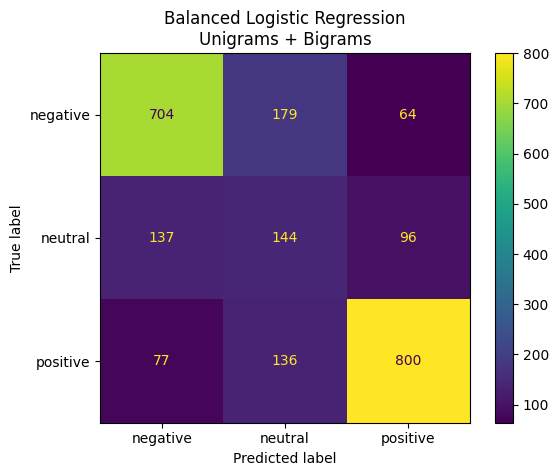

In [25]:
final_confusion_matrix = confusion_matrix(
    y_test,
    balanced_logreg_bigram_predictions,
    labels=LABELS
)

final_confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=LABELS
)

final_confusion_display.plot()
plt.title(
    "Balanced Logistic Regression\n"
    "Unigrams + Bigrams"
)
plt.show()

In [26]:
from pathlib import Path
import joblib


models_directory = Path("../models")
models_directory.mkdir(parents=True, exist_ok=True)

vectorizer_path = models_directory / "tfidf_unigram_bigram.joblib"
model_path = models_directory / "balanced_logreg_bigram.joblib"

joblib.dump(
    tfidf_unigram_bigram,
    vectorizer_path
)

joblib.dump(
    balanced_logreg_bigram_model,
    model_path
)

print("Vectorizer saved to:", vectorizer_path)
print("Model saved to:", model_path)

Vectorizer saved to: ../models/tfidf_unigram_bigram.joblib
Model saved to: ../models/balanced_logreg_bigram.joblib


In [27]:
assert vectorizer_path.exists()
assert model_path.exists()

print("Both final artifacts exist.")

Both final artifacts exist.


In [28]:
loaded_vectorizer = joblib.load(
    vectorizer_path
)

loaded_model = joblib.load(
    model_path
)

print("Saved artifacts loaded successfully.")

Saved artifacts loaded successfully.


In [29]:
reloaded_test_features = loaded_vectorizer.transform(
    x_test
)

reloaded_predictions = loaded_model.predict(
    reloaded_test_features
)

assert np.array_equal(
    balanced_logreg_bigram_predictions,
    reloaded_predictions
)

print("Reloaded model reproduces the original predictions.")

Reloaded model reproduces the original predictions.


In [30]:
def normalize_review(text):
    if not isinstance(text, str):
        raise TypeError("Review must be provided as text.")

    normalized_text = " ".join(
        text.lower().strip().split()
    )

    if not normalized_text:
        raise ValueError("Review cannot be empty.")

    return normalized_text

In [31]:
def predict_sentiment(review_text):
    normalized_review = normalize_review(review_text)

    review_features = loaded_vectorizer.transform(
        [normalized_review]
    )

    predicted_sentiment = loaded_model.predict(
        review_features
    )[0]

    probability_values = loaded_model.predict_proba(
        review_features
    )[0]

    class_probabilities = {
        class_name: float(probability)
        for class_name, probability in zip(
            loaded_model.classes_,
            probability_values
        )
    }

    confidence = class_probabilities[
        predicted_sentiment
    ]

    return {
        "review": review_text,
        "normalized_review": normalized_review,
        "sentiment": predicted_sentiment,
        "confidence": confidence,
        "probabilities": class_probabilities
    }

In [32]:
test_reviews = [
    "This is the best app I have ever used",
    "The app is okay and does what I need",
    "Terrible update, nothing works anymore",
    "The design is nice but it crashes frequently",
    "not good"
]

for review in test_reviews:
    result = predict_sentiment(review)

    print("\nReview:", result["review"])
    print("Prediction:", result["sentiment"])
    print(
        "Confidence:",
        round(result["confidence"] * 100, 2),
        "%"
    )
    print("Probabilities:", result["probabilities"])


Review: This is the best app I have ever used
Prediction: positive
Confidence: 93.47 %
Probabilities: {'negative': 0.040061787767906136, 'neutral': 0.025243847776638326, 'positive': 0.9346943644554556}

Review: The app is okay and does what I need
Prediction: positive
Confidence: 51.89 %
Probabilities: {'negative': 0.16342872411747802, 'neutral': 0.3176835779746482, 'positive': 0.5188876979078738}

Review: Terrible update, nothing works anymore
Prediction: negative
Confidence: 79.71 %
Probabilities: {'negative': 0.7970667240475059, 'neutral': 0.09755789924259625, 'positive': 0.10537537670989788}

Review: The design is nice but it crashes frequently
Prediction: positive
Confidence: 42.49 %
Probabilities: {'negative': 0.28251682892813273, 'neutral': 0.29259918567449184, 'positive': 0.42488398539737543}

Review: not good
Prediction: negative
Confidence: 80.63 %
Probabilities: {'negative': 0.8062807967375782, 'neutral': 0.12459861721073005, 'positive': 0.06912058605169176}


In [36]:
def predict_sentiment_batch(review_texts):
    if not isinstance(review_texts, (list, tuple, pd.Series)):
        raise TypeError(
            "review_texts must be a list, tuple, or pandas Series."
        )

    if len(review_texts) == 0:
        raise ValueError("At least one review is required.")

    normalized_reviews = []

    for review in review_texts:
        normalized_reviews.append(
            normalize_review(review)
        )

    review_features = loaded_vectorizer.transform(
        normalized_reviews
    )

    predictions = loaded_model.predict(
        review_features
    )

    probability_matrix = loaded_model.predict_proba(
        review_features
    )

    results = pd.DataFrame({
        "review": list(review_texts),
        "normalized_review": normalized_reviews,
        "sentiment": predictions
    })

    for class_index, class_name in enumerate(
        loaded_model.classes_
    ):
        results[f"{class_name}_probability"] = (
            probability_matrix[:, class_index]
        )

    results["confidence"] = probability_matrix.max(
        axis=1
    )

    def confidence_label(confidence):
        if confidence >= 0.80:
            return "high"
        elif confidence >= 0.60:
            return "medium"
        else:
            return "low"


    results["confidence_level"] = results[
        "confidence"
    ].apply(confidence_label)

    return results

In [37]:
batch_test_reviews = [
    "This app is amazing and very useful",
    "The update ruined everything",
    "It is okay, nothing special",
    "The interface looks good but it keeps crashing",
    "not good"
]

batch_results = predict_sentiment_batch(
    batch_test_reviews
)

display(batch_results)

,review,normalized_review,sentiment,negative_probability,neutral_probability,positive_probability,confidence,confidence_level
0,This app is amazing and very useful,this app is amazing and very useful,positive,0.062197,0.064090,0.873713,0.873713,high
1,The update ruined everything,the update ruined everything,negative,0.575630,0.253473,0.170897,0.575630,low
2,"It is okay, nothing special","it is okay, nothing special",negative,0.587323,0.256847,0.155829,0.587323,low
3,The interface looks good but it keeps crashing,the interface looks good but it keeps crashing,neutral,0.317005,0.510632,0.172363,0.510632,low
4,not good,not good,negative,0.806281,0.124599,0.069121,0.806281,high


In [38]:
def find_review_column(dataframe, preferred_column=None):
    if preferred_column is not None:
        if preferred_column not in dataframe.columns:
            raise ValueError(
                f"Column '{preferred_column}' was not found. "
                f"Available columns: {list(dataframe.columns)}"
            )

        return preferred_column

    possible_columns = [
        "content",
        "review",
        "review_text",
        "text",
        "comment",
        "feedback"
    ]

    lowercase_column_map = {
        str(column).strip().lower(): column
        for column in dataframe.columns
    }

    for possible_column in possible_columns:
        if possible_column in lowercase_column_map:
            return lowercase_column_map[possible_column]

    raise ValueError(
        "Could not automatically find a review-text column. "
        f"Available columns: {list(dataframe.columns)}"
    )

In [40]:
from pathlib import Path


def process_review_csv(
    input_csv_path,
    output_csv_path=None,
    review_column=None
):
    input_path = Path(input_csv_path)

    if not input_path.exists():
        raise FileNotFoundError(
            f"Input CSV was not found: {input_path}"
        )

    if input_path.suffix.lower() != ".csv":
        raise ValueError(
            "The input file must have a .csv extension."
        )

    dataframe = pd.read_csv(input_path)

    if dataframe.empty:
        raise ValueError("The uploaded CSV contains no rows.")

    detected_review_column = find_review_column(
        dataframe,
        preferred_column=review_column
    )

    print("Review column:", detected_review_column)

    output_dataframe = dataframe.copy()

    output_dataframe["normalized_review"] = pd.NA
    output_dataframe["predicted_sentiment"] = pd.NA
    output_dataframe["negative_probability"] = np.nan
    output_dataframe["neutral_probability"] = np.nan
    output_dataframe["positive_probability"] = np.nan
    output_dataframe["confidence"] = np.nan
    output_dataframe["confidence_level"] = pd.NA
    output_dataframe["prediction_status"] = "invalid_review"
    output_dataframe["error_message"] = (
        "Review text is missing or blank."
    )

    valid_review_mask = (
        output_dataframe[detected_review_column]
        .notna()
        &
        output_dataframe[detected_review_column]
        .astype(str)
        .str.strip()
        .ne("")
    )

    valid_row_indices = output_dataframe.index[
        valid_review_mask
    ]

    if len(valid_row_indices) == 0:
        raise ValueError(
            "No valid review text was found in the CSV."
        )

    valid_review_texts = (
        output_dataframe.loc[
            valid_row_indices,
            detected_review_column
        ]
        .astype(str)
    )

    prediction_results = predict_sentiment_batch(
        valid_review_texts
    )

    output_dataframe.loc[
        valid_row_indices,
        "normalized_review"
    ] = prediction_results[
        "normalized_review"
    ].to_numpy()

    output_dataframe.loc[
        valid_row_indices,
        "predicted_sentiment"
    ] = prediction_results[
        "sentiment"
    ].to_numpy()

    output_dataframe.loc[
        valid_row_indices,
        "negative_probability"
    ] = prediction_results[
        "negative_probability"
    ].to_numpy()

    output_dataframe.loc[
        valid_row_indices,
        "neutral_probability"
    ] = prediction_results[
        "neutral_probability"
    ].to_numpy()

    output_dataframe.loc[
        valid_row_indices,
        "positive_probability"
    ] = prediction_results[
        "positive_probability"
    ].to_numpy()

    output_dataframe.loc[
        valid_row_indices,
        "confidence"
    ] = prediction_results[
        "confidence"
    ].to_numpy()

    output_dataframe.loc[
        valid_row_indices,
        "confidence_level"
    ] = prediction_results[
        "confidence_level"
    ].to_numpy()

    output_dataframe.loc[
        valid_row_indices,
        "prediction_status"
    ] = "success"

    output_dataframe.loc[
        valid_row_indices,
        "error_message"
    ] = pd.NA

    if output_csv_path is None:
        output_path = input_path.with_name(
            f"{input_path.stem}_predictions.csv"
        )
    else:
        output_path = Path(output_csv_path)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    output_dataframe.to_csv(
        output_path,
        index=False
    )

    valid_row_count = int(valid_review_mask.sum())
    invalid_row_count = len(output_dataframe) - valid_row_count

    print("Original rows:", len(dataframe))
    print("Output rows:", len(output_dataframe))
    print("Successfully processed:", valid_row_count)
    print("Invalid rows preserved:", invalid_row_count)
    print("Output saved to:", output_path)

    return output_dataframe, output_path

In [41]:
csv_results, csv_output_path = process_review_csv(
    input_csv_path="../data/raw/reviews.csv",
    output_csv_path="../data/processed/reviews_predictions.csv",
    review_column="content"
)

Review column: content
Original rows: 12495
Output rows: 12495
Successfully processed: 12495
Invalid rows preserved: 0
Output saved to: ../data/processed/reviews_predictions.csv


In [42]:
assert len(csv_results) == len(reviews)

print(
    csv_results["prediction_status"].value_counts()
)

display(
    csv_results[
        [
            "content",
            "predicted_sentiment",
            "confidence",
            "confidence_level",
            "prediction_status",
            "error_message"
        ]
    ].head(10)
)

prediction_status
success    12495
Name: count, dtype: int64


,content,predicted_sentiment,confidence,confidence_level,prediction_status,error_message
0,I cannot open the app anymore,negative,0.719931,medium,success,<NA>
1,I have been begging for a refund from this app...,negative,0.556051,low,success,<NA>
2,Very costly for the premium version (approx In...,negative,0.458426,low,success,<NA>
3,"Used to keep me organized, but all the 2020 UP...",negative,0.417155,low,success,<NA>
4,Dan Birthday Oct 28,negative,0.398411,low,success,<NA>
5,It has changed how I viewed my different lists...,positive,0.371248,low,success,<NA>
6,I'm only looking for a grocery list app but ev...,negative,0.698807,medium,success,<NA>
7,"Reset my free trial, new phone I'd like to see...",negative,0.453870,low,success,<NA>
8,How do to stop monthly payment because i don't...,negative,0.838937,high,success,<NA>
9,I complain about not crashes and it was immedi...,negative,0.744882,medium,success,<NA>


In [43]:
assert len(csv_results) == len(reviews)